In [8]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset.csv


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

In [10]:
df = pd.read_csv("retail_sales_dataset.csv")

In [11]:
# Display first 5 rows
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [12]:
print("Shape of Dataset:", df.shape)

df.info()

Shape of Dataset: (1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [13]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [15]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [16]:
df['Date'] = pd.to_datetime(df['Date'])

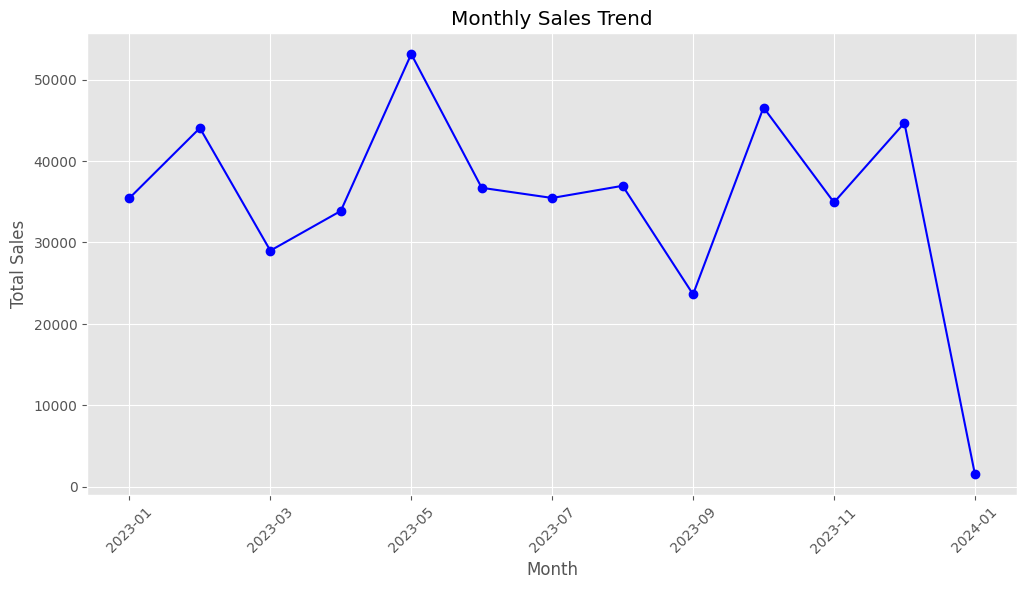

In [17]:
# Create Month-Year column
df['Month'] = df['Date'].dt.to_period('M')

# Calculate monthly sales
monthly_sales = df.groupby('Month')['Total Amount'].sum()

# Convert Period to string for plotting
monthly_sales.index = monthly_sales.index.astype(str)

# Plot
plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o', color='blue')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

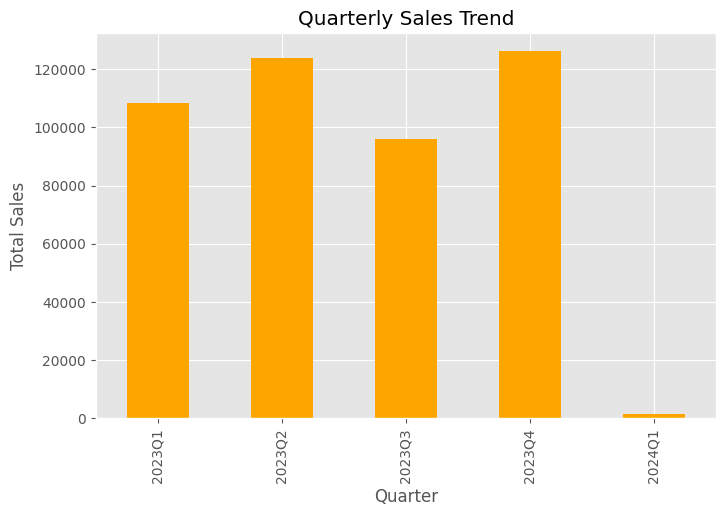

In [18]:
# Create Quarter column
df['Quarter'] = df['Date'].dt.to_period('Q')

quarterly_sales = df.groupby('Quarter')['Total Amount'].sum()

quarterly_sales.index = quarterly_sales.index.astype(str)

plt.figure(figsize=(8,5))
quarterly_sales.plot(kind='bar', color='orange')

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.show()

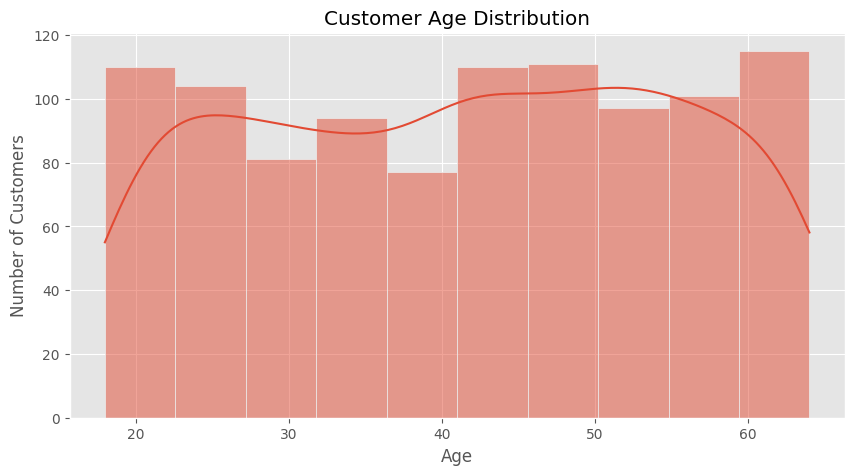

In [19]:
plt.figure(figsize=(10,5))

sns.histplot(df['Age'], bins=10, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

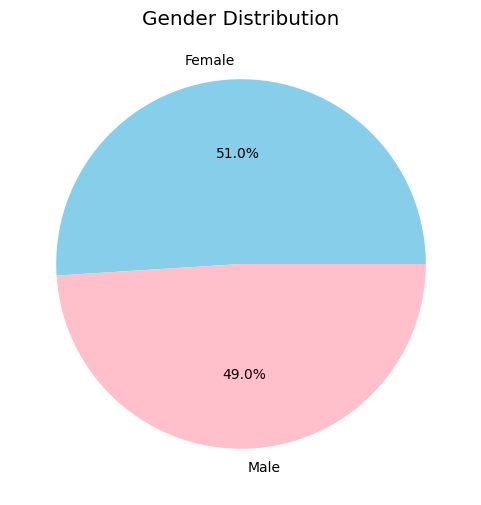

In [20]:
plt.figure(figsize=(6,6))

df['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['skyblue','pink']
)

plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

/tmp/ipykernel_1866/1978687264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Product Category', palette='viridis')


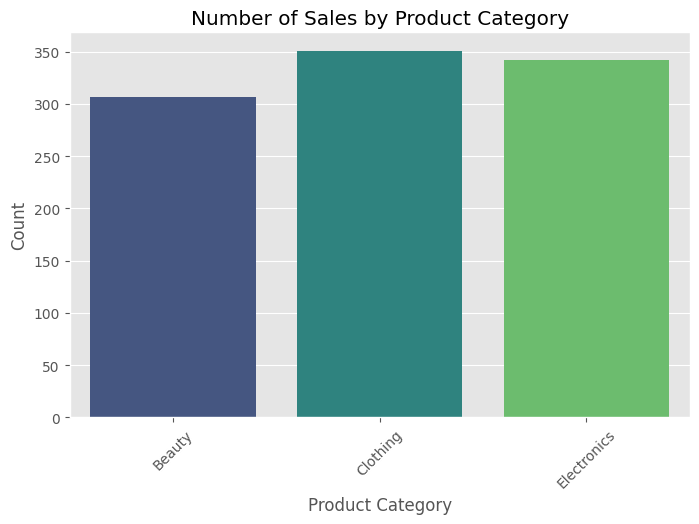

In [21]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Product Category', palette='viridis')

plt.title("Number of Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

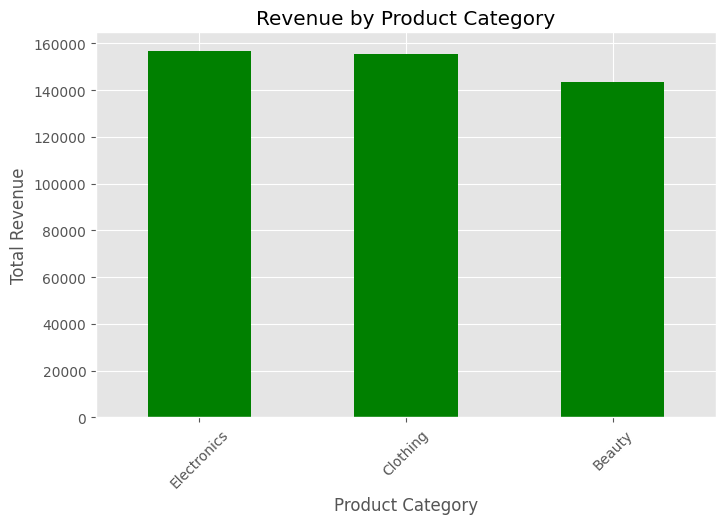

In [22]:
plt.figure(figsize=(8,5))

df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False).plot(
    kind='bar',
    color='green'
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

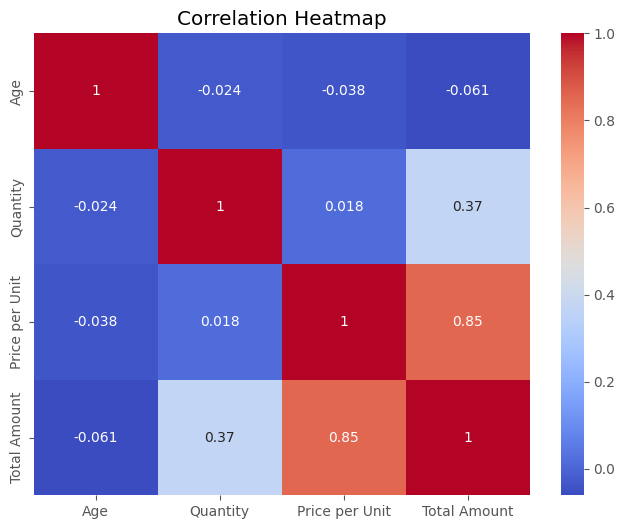

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Age','Quantity','Price per Unit','Total Amount']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

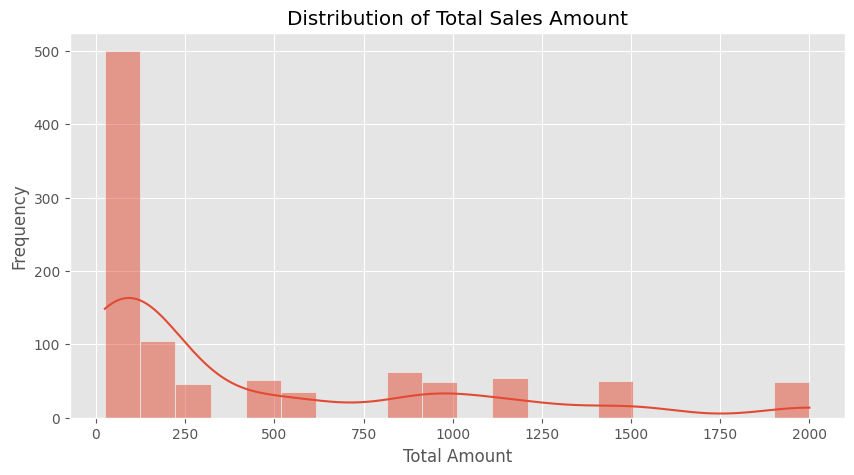

In [24]:
plt.figure(figsize=(10,5))

sns.histplot(df['Total Amount'], bins=20, kde=True)

plt.title("Distribution of Total Sales Amount")
plt.xlabel("Total Amount")
plt.ylabel("Frequency")
plt.show()

In [25]:
print("""
Business Recommendations

1. Increase stock for the highest revenue-generating product categories.

2. Launch marketing campaigns targeting the age groups with the highest purchasing activity.

3. Offer personalized promotions to both male and female customers based on purchasing patterns.

4. Monitor monthly and quarterly sales trends to plan inventory and promotional campaigns effectively.

5. Focus on products with consistently high sales to maximize overall revenue.
""")


Business Recommendations

1. Increase stock for the highest revenue-generating product categories.

2. Launch marketing campaigns targeting the age groups with the highest purchasing activity.

3. Offer personalized promotions to both male and female customers based on purchasing patterns.

4. Monitor monthly and quarterly sales trends to plan inventory and promotional campaigns effectively.

5. Focus on products with consistently high sales to maximize overall revenue.



# Conclusion

The Exploratory Data Analysis (EDA) of the Retail Sales Dataset provided valuable insights into customer behavior and sales performance.

## Key Findings
- The dataset was successfully loaded, inspected, and cleaned for analysis.
- Monthly and quarterly sales trends revealed variations in sales over time.
- Customer demographics (Age and Gender) helped identify the primary customer groups.
- Product category analysis showed which categories generated the highest sales and revenue.
- Correlation analysis helped understand the relationships between numerical variables such as Age, Quantity, Price per Unit, and Total Amount.

## Business Recommendations
- Focus on high-performing product categories to increase revenue.
- Target marketing campaigns toward the most active customer age groups.
- Monitor monthly and quarterly sales trends for better inventory planning.
- Use customer demographic insights to create personalized promotions.

## Final Summary
This analysis demonstrates how data analytics can help businesses understand customer behavior, optimize sales strategies, and support data-driven decision-making. The findings can be used to improve marketing, inventory management, and overall business performance.